Saving 0000.csv to 0000 (1).csv
Loaded: 0000 (1).csv
Original columns: ['SaO2', 'PR', 'EEG(sec)', 'ECG', 'EMG', 'EOG(L)', 'EOG(R)', 'EEG', 'AIRFLOW', 'THOR RES', 'ABDO RES', 'sample_index']
Using features: ['SaO2', 'PR', 'EEG(sec)', 'ECG', 'EMG', 'EOG(L)', 'EOG(R)', 'EEG', 'AIRFLOW', 'THOR RES', 'ABDO RES']
Shape: (32399, 11)
Subsequence length (m): 100
Prepared 11 dimensions for mstump.
Computing multivariate matrix profile with mstump... (may take time)
mstump finished. raw mp shape: (11, 32300) mpi shape: (11, 32300)
Aggregated mp shape (n_windows): (32300,)
Top-20 discord window start indices: [3368 2999 3238 3237  787  780  786 3239  788 3230 3222 3221 3240 3236
 3229  785 3231 3241 3000 3228]
Percent of samples flagged anomalous (top-20 discords): 1.324%


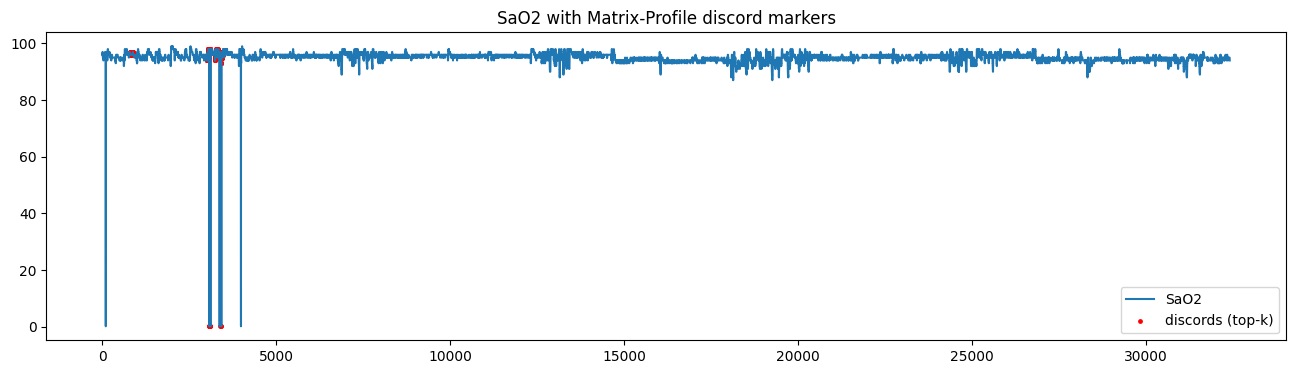

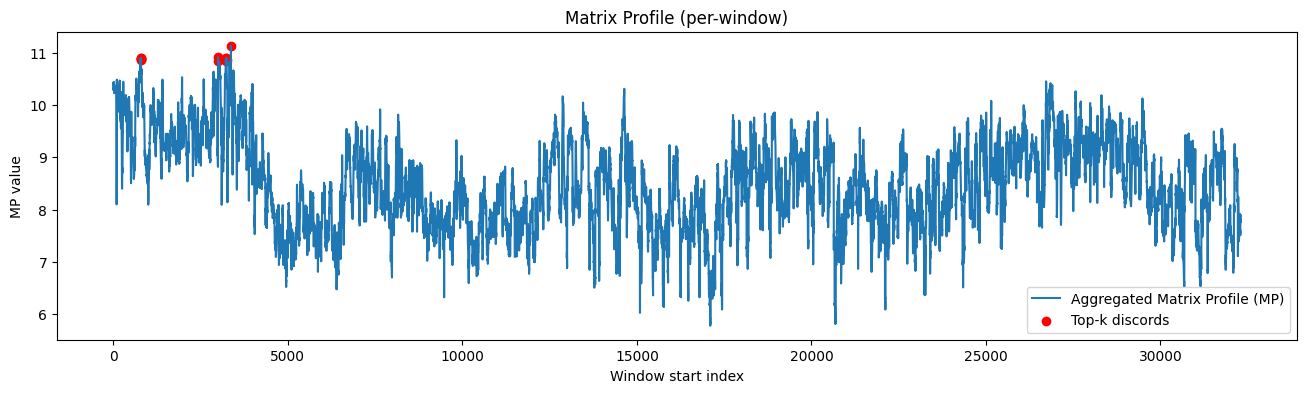

Top discord windows (rank, start, mp_value):
Rank 1: start=3368, mp_value=11.133509
Rank 2: start=2999, mp_value=10.914695
Rank 3: start=3238, mp_value=10.904700
Rank 4: start=3237, mp_value=10.899736
Rank 5: start=787, mp_value=10.899284
Rank 6: start=780, mp_value=10.889956
Rank 7: start=786, mp_value=10.888606
Rank 8: start=3239, mp_value=10.885399
Rank 9: start=788, mp_value=10.877375
Rank 10: start=3230, mp_value=10.876188
Rank 11: start=3222, mp_value=10.871054
Rank 12: start=3221, mp_value=10.868908
Rank 13: start=3240, mp_value=10.868310
Rank 14: start=3236, mp_value=10.867577
Rank 15: start=3229, mp_value=10.867242
Rank 16: start=785, mp_value=10.865603
Rank 17: start=3231, mp_value=10.859711
Rank 18: start=3241, mp_value=10.852051
Rank 19: start=3000, mp_value=10.848402
Rank 20: start=3228, mp_value=10.847856


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: matrix_profile_mp_agg.npy , matrix_profile_mpi.npy , mp_anomaly_by_sample.csv


In [ ]:
!pip install -q stumpy pandas numpy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stumpy
from google.colab import files
import os
import warnings
warnings.filterwarnings("ignore")

uploaded = files.upload()  
csv_filename = list(uploaded.keys())[0]
print("Loaded:", csv_filename)

df = pd.read_csv(csv_filename)
print("Original columns:", df.columns.tolist())

if 'sample_index' in df.columns:
    df = df.drop(columns=['sample_index'])

df = df.select_dtypes(include=[np.number]).copy()
print("Using features:", df.columns.tolist())
n_samples, n_features = df.shape
print("Shape:", df.shape)

df = df.interpolate().fillna(method='bfill').fillna(method='ffill')

m = 100  
print("Subsequence length (m):", m)

time_series_list = [df[col].values.astype(float) for col in df.columns.tolist()]
n_dims = len(time_series_list)
print(f"Prepared {n_dims} dimensions for mstump.")

print("Computing multivariate matrix profile with mstump... (may take time)")
mp, mpi = stumpy.mstump(time_series_list, m)
print("mstump finished. raw mp shape:", np.shape(mp), "mpi shape:", np.shape(mpi))


if np.ndim(mp) == 1:
    mp_agg = mp
elif np.ndim(mp) == 2:

    if mp.shape[0] == n_dims:
    
        mp_agg = np.mean(mp, axis=0)
    elif mp.shape[1] == n_dims:
        
        mp_agg = np.mean(mp, axis=1)
    else:
      
        mp_agg = np.mean(mp, axis=0)
else:
 
    mp_agg = np.mean(np.asarray(mp), axis=0)

mp_agg = np.asarray(mp_agg)
n_windows = len(mp_agg)
print("Aggregated mp shape (n_windows):", mp_agg.shape)

k = 20
if k > n_windows:
    k = n_windows
top_k_idx = np.argsort(mp_agg)[-k:][::-1] 
print(f"Top-{k} discord window start indices:", top_k_idx)

sample_anomaly = np.zeros(n_samples, dtype=int)
for win_start in top_k_idx:
    start = int(win_start)
    end = int(start + m)
    if end > n_samples:
        end = n_samples
    sample_anomaly[start:end] = 1  

pct_samples = sample_anomaly.sum() / n_samples * 100
print(f"Percent of samples flagged anomalous (top-{k} discords): {pct_samples:.3f}%")

feature_to_plot = 0
feature_name = df.columns[feature_to_plot]
plt.figure(figsize=(16,4))
plt.plot(np.arange(n_samples), df.iloc[:, feature_to_plot].values, label=feature_name)
anom_idxs = np.where(sample_anomaly==1)[0]
plt.scatter(anom_idxs, df.iloc[anom_idxs, feature_to_plot], color='red', s=6, label='discords (top-k)')
plt.legend(); plt.title(f"{feature_name} with Matrix-Profile discord markers"); plt.show()


plt.figure(figsize=(16,4))
plt.plot(np.arange(n_windows), mp_agg, label='Aggregated Matrix Profile (MP)')
plt.scatter(top_k_idx, mp_agg[top_k_idx], color='red', label='Top-k discords')
plt.xlabel("Window start index"); plt.ylabel("MP value"); plt.legend(); plt.title("Matrix Profile (per-window)"); plt.show()

print("Top discord windows (rank, start, mp_value):")
for rank, idx in enumerate(top_k_idx, 1):
    print(f"Rank {rank}: start={int(idx)}, mp_value={mp_agg[int(idx)]:.6f}")

np.save("matrix_profile_mp_agg.npy", mp_agg)
np.save("matrix_profile_mpi.npy", mpi)
pd.DataFrame({'sample_index': np.arange(n_samples), 'is_anomaly_mp_topk': sample_anomaly}).to_csv("mp_anomaly_by_sample.csv", index=False)

files.download("matrix_profile_mp_agg.npy")
files.download("matrix_profile_mpi.npy")
files.download("mp_anomaly_by_sample.csv")

print("Saved: matrix_profile_mp_agg.npy , matrix_profile_mpi.npy , mp_anomaly_by_sample.csv")
